# HDFS에서 파일 읽어오기

In [1]:
# !pip install hdfs

In [2]:
!hostname -I

172.17.0.2 172.20.0.6 


In [3]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Text(0.2, 0.4, '한글')

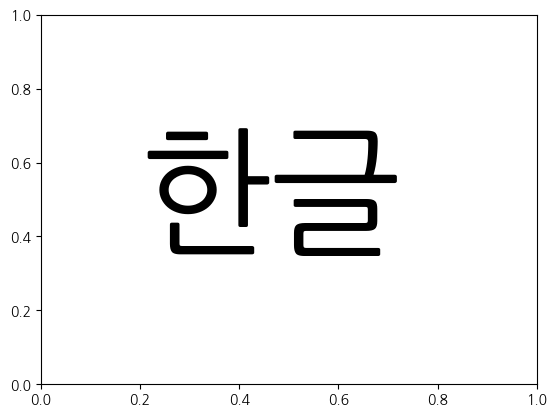

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [5]:
client_hdfs = InsecureClient('http://namenode:9870',user='hadoop')
path = "/dataset/행정구역시도성연령별취업자202606.csv"

with client_hdfs.read(path, encoding='euc-kr') as reader:
    data = pd.read_csv(reader)


data.columns = ['year', 'region', 'gender', 'age', 'value']
# styled_data = data.head(10).style.set_table_styles([
#     {'selector':'th,td','props':[
#         ('text-align','center'),
#         ('border','1px solid #ccc')
#     ]}
# ])
# styled_data
data

,year,region,gender,age,value
0,2015.1/4,서울특별시,남자,20 - 29세,322
1,2015.1/4,서울특별시,남자,30 - 39세,752
2,2015.1/4,서울특별시,남자,40 - 49세,750
3,2015.1/4,서울특별시,남자,50 - 59세,669
4,2015.1/4,서울특별시,남자,60세이상,366
...,...,...,...,...,...
7645,2026.1/4,제주도,여자,20 - 29세,20
7646,2026.1/4,제주도,여자,30 - 39세,29
7647,2026.1/4,제주도,여자,40 - 49세,41
7648,2026.1/4,제주도,여자,50 - 59세,48


In [6]:
data2 = data.copy()
data2['value'] = pd.to_numeric(data2['value'], errors='coerce')
data2.dtypes

year          str
region        str
gender        str
age           str
value     float64
dtype: object

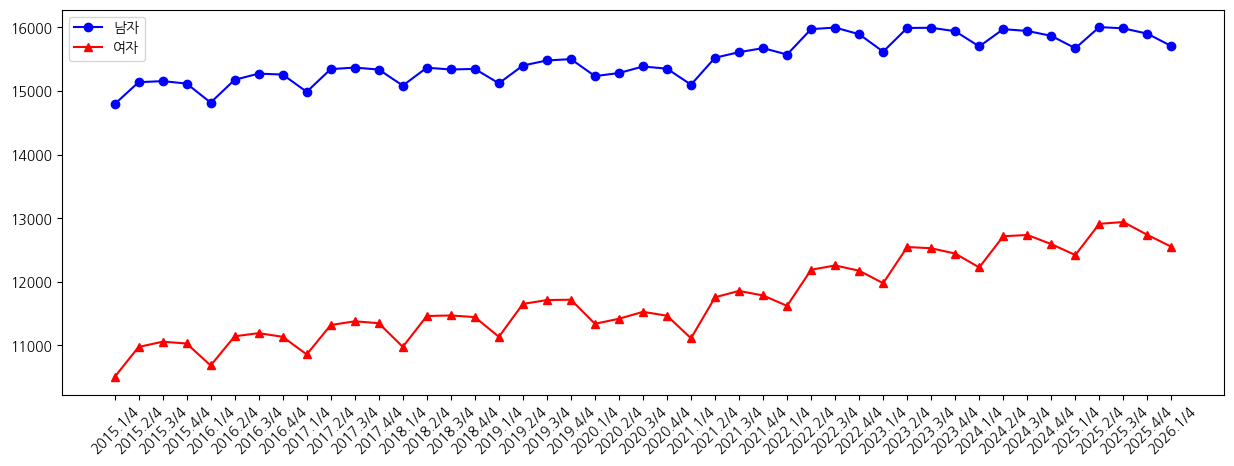

In [7]:
data3 = data2.groupby(['year','gender'])['value'].sum().reset_index(name='total')

# 분리적재
male = data3[data3['gender'] =='남자']
female = data3[data3['gender'] =='여자']

# 시각화
fig , ax = plt.subplots(figsize=(15,5))

ax.plot(male['year'], male['total'], label='남자', color='blue', linestyle='-', marker='o')
ax.plot(female['year'], female['total'], label='여자', color='red', linestyle='-', marker='^')

ax.set_xticks(male['year'])
ax.set_xticklabels(male['year'], rotation=45)
ax.legend()
plt.show()

## 전국 청년과 60대 이상 취업자수 관계

In [31]:
from hdfs import InsecureClient
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
client_hdfs = InsecureClient('http://namenode:9870',user='hadoop')
path = "/dataset/행정구역시도성연령별취업자202606.csv"

with client_hdfs.read(path, encoding='euc-kr') as reader:
    data = pd.read_csv(reader)
data.columns = ['year','city','gender','age','value']

In [33]:
data['value'] = data['value'].replace('-',0).astype('float')
data.dtypes

year          str
city          str
gender        str
age           str
value     float64
dtype: object

In [40]:
mydata = data[data['year'] >= "2025.1/4"]
mydata

,year,city,gender,age,value
6800,2025.1/4,서울특별시,남자,20 - 29세,323.0
6801,2025.1/4,서울특별시,남자,30 - 39세,652.0
6802,2025.1/4,서울특별시,남자,40 - 49세,595.0
6803,2025.1/4,서울특별시,남자,50 - 59세,604.0
6804,2025.1/4,서울특별시,남자,60세이상,529.0
...,...,...,...,...,...
7645,2026.1/4,제주도,여자,20 - 29세,20.0
7646,2026.1/4,제주도,여자,30 - 39세,29.0
7647,2026.1/4,제주도,여자,40 - 49세,41.0
7648,2026.1/4,제주도,여자,50 - 59세,48.0


In [44]:
x_data = mydata[mydata['age'].isin(['20 - 29세'])]
y_data = mydata[mydata['age'].isin(['60세이상'])]
z_data = mydata
xx = x_data.groupby('city')['value'].sum() #.reset_index(name='total')  # 20대 취업자
yy = y_data.groupby('city')['value'].sum() #.reset_index(name='total')  # 60대(정년퇴임) 취업자
zz = z_data.groupby('city')['value'].sum() #.reset_index(name='total')  # 전체 취업자

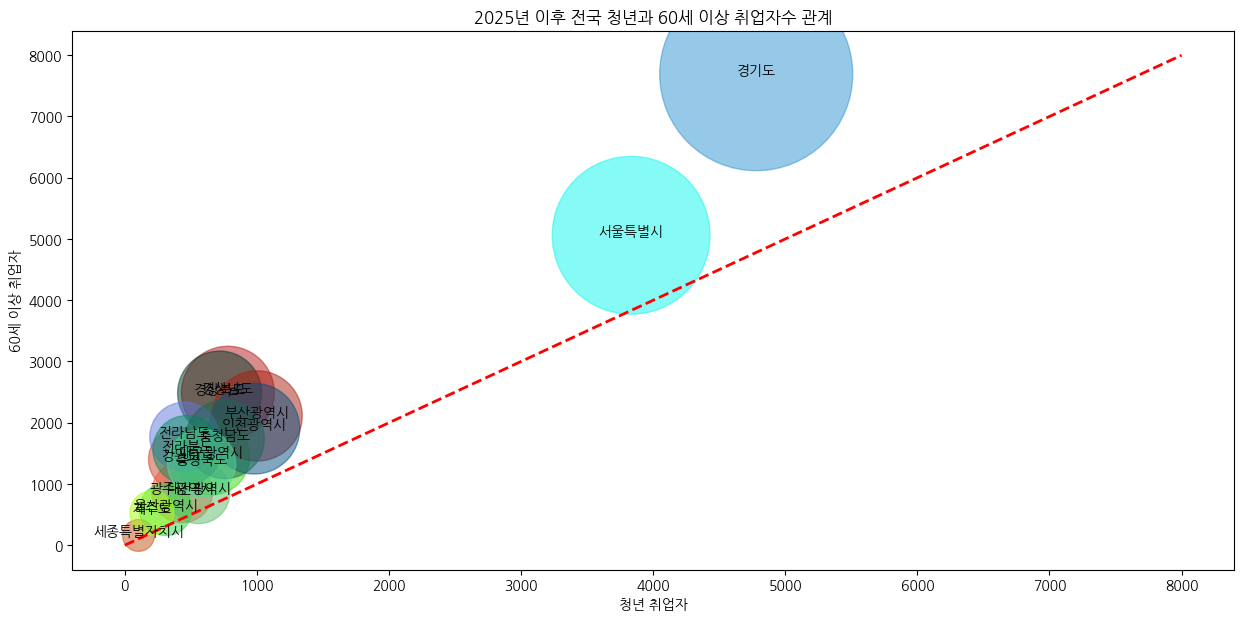

In [53]:
import numpy as np

legions = list(xx.index) # 라벨
color = [ np.random.rand(3,) for _ in range(len(legions))]

fig , ax = plt.subplots(figsize=(15,7))
ax.scatter(xx, yy, s=zz * 0.5, c=color, alpha= 0.5)

for n in range(len(legions)):
    ax.annotate(legions[n], xy=(xx.iloc[n],yy.iloc[n]), ha="center")

ax.plot([0,8000], [0,8000], color='r', linestyle='--', linewidth=2)

ax.set_title("2025년 이후 전국 청년과 60세 이상 취업자수 관계")
ax.set_xlabel("청년 취업자")
ax.set_ylabel("60세 이상 취업자")
plt.show()

# 인사이트
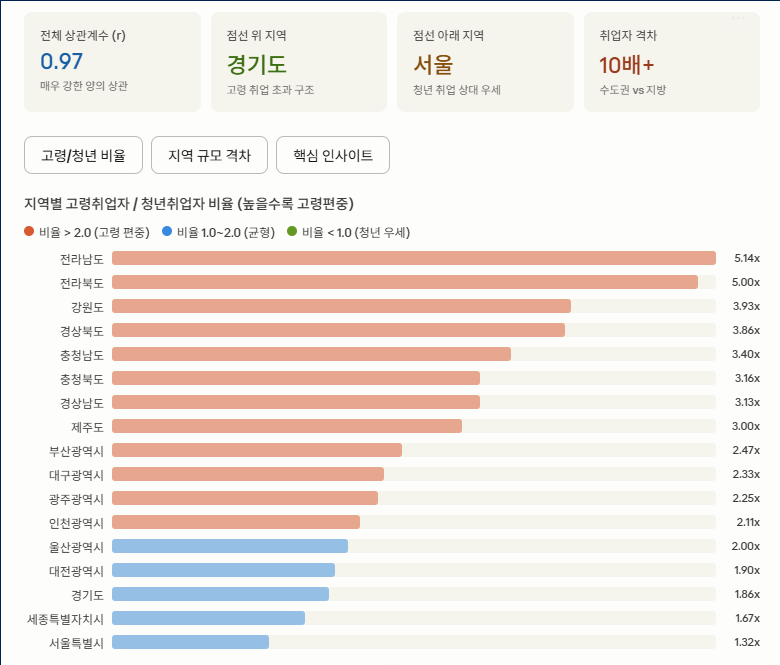

1. 상관관계 (r ≈ 0.97) — "규모의 법칙"
청년 취업자가 많은 곳에 고령 취업자도 많다. 이건 지역 경제 총규모가 두 지표를 동시에 끌어올리기 때문이다. 즉, 이 상관관계는 "청년과 고령이 같은 일자리를 두고 경쟁한다"는 의미가 아니라 "경제가 크면 다 많다"는 자명한 사실을 보여줄 뿐이다.

2. 균형선(점선) 위/아래 — 구조 차이가 핵심
지역위치해석경기도점선 위고령 취업 초과 → 제조·물류·농업 고령 친화 일자리 多서울점선 근처균형 → IT·금융·서비스 청년 흡수력지방 대부분점선 위고령비율 높음 → 청년 유출 + 고령 잔류 구조

3. 수도권 vs 지방 — 10배 이상 격차
절대 수치 자체가 너무 차이나서 지방 지역들이 전부 좌하단에 군집처럼 보인다. 이건 정책적으로 심각한 문제 — 지방에서는 청년도, 고령자도 취업 기회 자체가 부족하다.